# Experimentos MLP do Zero — MNIST


In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

from mlp.network import MLP
from mlp.optimizers import SGD, SGDMomentum, Adam


In [2]:
import torchvision
print(torchvision.__version__)

0.27.0+cpu


## 1. Carregamento e pré-processamento dos dados


In [3]:
# Tenta keras primeiro, cai em torchvision se não tiver
try:
    from tensorflow.keras.datasets import mnist
    (X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()
    print('Dados carregados via Keras')
except ImportError:
    import torchvision
    train_ds = torchvision.datasets.MNIST('.', train=True, download=True)
    test_ds  = torchvision.datasets.MNIST('.', train=False, download=True)
    X_train_raw = train_ds.data.numpy()
    y_train     = train_ds.targets.numpy()
    X_test_raw  = test_ds.data.numpy()
    y_test      = test_ds.targets.numpy()
    print('Dados carregados via torchvision')

# Flatten (28x28 -> 784) e normalização [0, 1]
X_train = X_train_raw.reshape(-1, 784).astype(np.float32) / 255.0
X_test  = X_test_raw.reshape(-1, 784).astype(np.float32) / 255.0

# One-hot encoding
def to_one_hot(y, n_classes=10):
    oh = np.zeros((len(y), n_classes), dtype=np.float32)
    oh[np.arange(len(y)), y] = 1.0
    return oh

y_train_oh = to_one_hot(y_train)
y_test_oh  = to_one_hot(y_test)

print(f'Treino: {X_train.shape}, Teste: {X_test.shape}')
print(f'Classes: {np.unique(y_train)}')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
Dados carregados via Keras
Treino: (60000, 784), Teste: (10000, 784)
Classes: [0 1 2 3 4 5 6 7 8 9]


## 2. Experimento 1 — Arquitetura principal (784→256→128→10, ReLU, Adam)


In [4]:
np.random.seed(42)

model1 = MLP(layer_sizes=[784, 256, 128, 10], activation='relu')
opt1   = Adam(learning_rate=0.001)

history1 = model1.train(
    X_train, y_train_oh, y_train,
    X_test, y_test,
    optimizer=opt1,
    epochs=20,
    batch_size=128
)

test_acc1 = model1.compute_accuracy(X_test, y_test)
print(f'\nAcurácia final no teste (Exp 1): {test_acc1:.4f}')


Época   1/20 | Loss: 0.2657 | Treino: 0.9682 | Val: 0.9637
Época   2/20 | Loss: 0.1013 | Treino: 0.9797 | Val: 0.9707
Época   3/20 | Loss: 0.0658 | Treino: 0.9832 | Val: 0.9712
Época   4/20 | Loss: 0.0477 | Treino: 0.9880 | Val: 0.9735
Época   5/20 | Loss: 0.0346 | Treino: 0.9942 | Val: 0.9799
Época   6/20 | Loss: 0.0261 | Treino: 0.9951 | Val: 0.9809
Época   7/20 | Loss: 0.0194 | Treino: 0.9957 | Val: 0.9777
Época   8/20 | Loss: 0.0178 | Treino: 0.9938 | Val: 0.9779
Época   9/20 | Loss: 0.0153 | Treino: 0.9935 | Val: 0.9732
Época  10/20 | Loss: 0.0129 | Treino: 0.9968 | Val: 0.9790
Época  11/20 | Loss: 0.0116 | Treino: 0.9933 | Val: 0.9771
Época  12/20 | Loss: 0.0097 | Treino: 0.9980 | Val: 0.9795
Época  13/20 | Loss: 0.0070 | Treino: 0.9946 | Val: 0.9772
Época  14/20 | Loss: 0.0146 | Treino: 0.9981 | Val: 0.9813
Época  15/20 | Loss: 0.0058 | Treino: 0.9989 | Val: 0.9806
Época  16/20 | Loss: 0.0085 | Treino: 0.9932 | Val: 0.9762
Época  17/20 | Loss: 0.0083 | Treino: 0.9980 | Val: 0.97

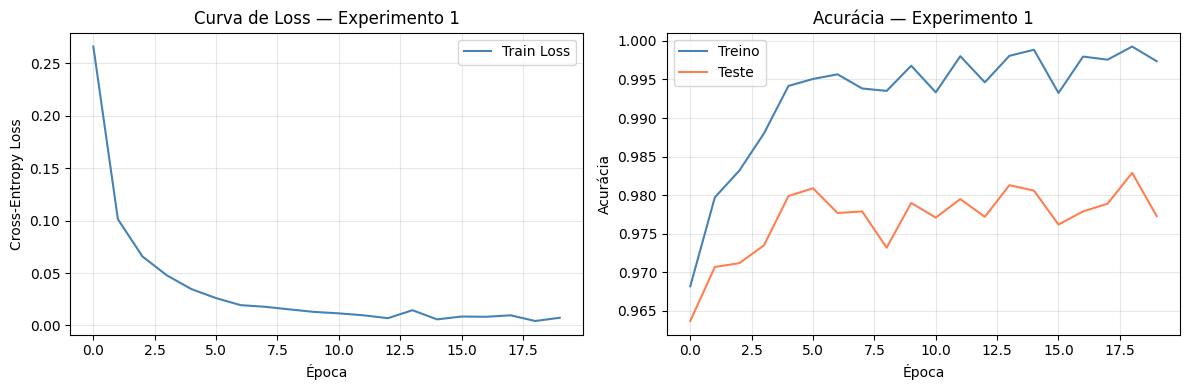

In [5]:
# Plot da curva de loss e acurácia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history1['train_loss'], label='Train Loss', color='steelblue')
ax1.set_title('Curva de Loss — Experimento 1')
ax1.set_xlabel('Época'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history1['train_acc'], label='Treino', color='steelblue')
ax2.plot(history1['val_acc'],   label='Teste',  color='coral')
ax2.set_title('Acurácia — Experimento 1')
ax2.set_xlabel('Época'); ax2.set_ylabel('Acurácia')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/exp1_loss_acc.png', dpi=120)
plt.show()


## 3. Experimento 2 — Rede menor com SGD + Momentum


In [6]:
np.random.seed(42)

model2 = MLP(layer_sizes=[784, 128, 64, 10], activation='relu')
opt2   = SGDMomentum(learning_rate=0.01, momentum=0.9)

history2 = model2.train(
    X_train, y_train_oh, y_train,
    X_test, y_test,
    optimizer=opt2,
    epochs=20,
    batch_size=128
)

test_acc2 = model2.compute_accuracy(X_test, y_test)
print(f'\nAcurácia final no teste (Exp 2): {test_acc2:.4f}')


Época   1/20 | Loss: 0.4564 | Treino: 0.9323 | Val: 0.9340
Época   2/20 | Loss: 0.2082 | Treino: 0.9501 | Val: 0.9480
Época   3/20 | Loss: 0.1554 | Treino: 0.9632 | Val: 0.9596
Época   4/20 | Loss: 0.1258 | Treino: 0.9696 | Val: 0.9650
Época   5/20 | Loss: 0.1059 | Treino: 0.9742 | Val: 0.9688
Época   6/20 | Loss: 0.0903 | Treino: 0.9785 | Val: 0.9692
Época   7/20 | Loss: 0.0778 | Treino: 0.9822 | Val: 0.9724
Época   8/20 | Loss: 0.0687 | Treino: 0.9839 | Val: 0.9727
Época   9/20 | Loss: 0.0613 | Treino: 0.9855 | Val: 0.9737
Época  10/20 | Loss: 0.0548 | Treino: 0.9870 | Val: 0.9745
Época  11/20 | Loss: 0.0492 | Treino: 0.9886 | Val: 0.9759
Época  12/20 | Loss: 0.0433 | Treino: 0.9901 | Val: 0.9760
Época  13/20 | Loss: 0.0394 | Treino: 0.9899 | Val: 0.9741
Época  14/20 | Loss: 0.0359 | Treino: 0.9923 | Val: 0.9759
Época  15/20 | Loss: 0.0327 | Treino: 0.9920 | Val: 0.9745
Época  16/20 | Loss: 0.0290 | Treino: 0.9927 | Val: 0.9760
Época  17/20 | Loss: 0.0261 | Treino: 0.9951 | Val: 0.97

## 4. Experimento 3 — Ativação tanh vs ReLU


In [7]:
np.random.seed(42)

model3 = MLP(layer_sizes=[784, 256, 128, 10], activation='tanh')
opt3   = Adam(learning_rate=0.001)

history3 = model3.train(
    X_train, y_train_oh, y_train,
    X_test, y_test,
    optimizer=opt3,
    epochs=20,
    batch_size=128
)

test_acc3 = model3.compute_accuracy(X_test, y_test)
print(f'\nAcurácia final no teste (Exp 3 - tanh): {test_acc3:.4f}')


Época   1/20 | Loss: 0.2905 | Treino: 0.9564 | Val: 0.9532
Época   2/20 | Loss: 0.1356 | Treino: 0.9709 | Val: 0.9646
Época   3/20 | Loss: 0.0931 | Treino: 0.9774 | Val: 0.9689
Época   4/20 | Loss: 0.0693 | Treino: 0.9837 | Val: 0.9700
Época   5/20 | Loss: 0.0519 | Treino: 0.9907 | Val: 0.9757
Época   6/20 | Loss: 0.0392 | Treino: 0.9928 | Val: 0.9780
Época   7/20 | Loss: 0.0294 | Treino: 0.9948 | Val: 0.9787
Época   8/20 | Loss: 0.0224 | Treino: 0.9966 | Val: 0.9793
Época   9/20 | Loss: 0.0176 | Treino: 0.9955 | Val: 0.9759
Época  10/20 | Loss: 0.0136 | Treino: 0.9985 | Val: 0.9786
Época  11/20 | Loss: 0.0103 | Treino: 0.9989 | Val: 0.9808
Época  12/20 | Loss: 0.0083 | Treino: 0.9988 | Val: 0.9784
Época  13/20 | Loss: 0.0094 | Treino: 0.9971 | Val: 0.9762
Época  14/20 | Loss: 0.0063 | Treino: 0.9994 | Val: 0.9804
Época  15/20 | Loss: 0.0056 | Treino: 0.9986 | Val: 0.9774
Época  16/20 | Loss: 0.0089 | Treino: 0.9966 | Val: 0.9777
Época  17/20 | Loss: 0.0086 | Treino: 0.9978 | Val: 0.97

## 5. Tabela Comparativa


In [8]:
print('=' * 70)
print(f'{"Experimento":<35} {"Otimizador":<15} {"Acurácia Teste"}')
print('=' * 70)
print(f'{"[784→256→128→10] ReLU":<35} {"Adam 0.001":<15} {test_acc1:.4f}')
print(f'{"[784→128→64→10] ReLU":<35} {"SGD+Mom 0.01":<15} {test_acc2:.4f}')
print(f'{"[784→256→128→10] Tanh":<35} {"Adam 0.001":<15} {test_acc3:.4f}')
print('=' * 70)


Experimento                         Otimizador      Acurácia Teste
[784→256→128→10] ReLU               Adam 0.001      0.9773
[784→128→64→10] ReLU                SGD+Mom 0.01    0.9765
[784→256→128→10] Tanh               Adam 0.001      0.9808


## 6. Matriz de Confusão


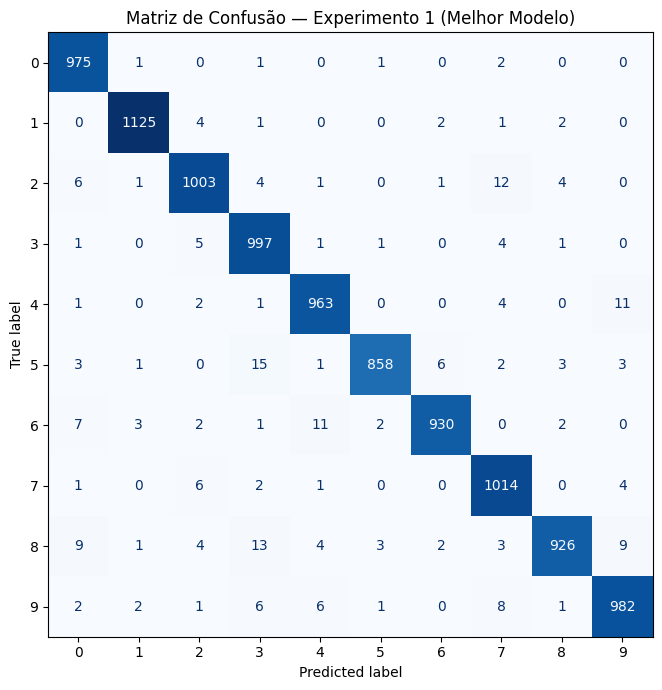

Par mais confundido: 5 classificado como 3 (15 vezes)


In [9]:
y_pred = model1.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusão — Experimento 1 (Melhor Modelo)')
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=120)
plt.show()

# Dígitos mais confundidos
np.fill_diagonal(cm, 0)
i, j = np.unravel_index(np.argmax(cm), cm.shape)
print(f'Par mais confundido: {i} classificado como {j} ({cm[i,j]} vezes)')


## 7. Gradient Check Numérico


In [10]:
from mlp.losses import cross_entropy_loss

def gradient_check(model, X_sample, y_sample_oh, epsilon=1e-5):
    """
    Compara gradiente analítico (backprop) com aproximação numérica.
    Se a diferença relativa for < 1e-5, os gradientes estão corretos.
    """
    model.forward(X_sample)
    grads_W, grads_b = model.backward(y_sample_oh)
    
    errors = []
    # Verifica apenas a primeira camada para ser rápido
    W = model.weights[0]
    analytical = grads_W[0]
    
    for idx in np.ndindex(W.shape[:2] if len(W.shape) > 1 else W.shape):
        if np.random.rand() > 0.01:  # amostra 1% dos parâmetros
            continue
        orig = W[idx]
        W[idx] = orig + epsilon
        loss_plus = cross_entropy_loss(model.forward(X_sample), y_sample_oh)
        W[idx] = orig - epsilon
        loss_minus = cross_entropy_loss(model.forward(X_sample), y_sample_oh)
        W[idx] = orig
        
        numerical = (loss_plus - loss_minus) / (2 * epsilon)
        diff = abs(numerical - analytical[idx]) / (abs(numerical) + abs(analytical[idx]) + 1e-12)
        errors.append(diff)
    
    max_err = max(errors) if errors else 0
    print(f'Gradient check — erro relativo máximo: {max_err:.2e}')
    print('✓ Gradientes corretos!' if max_err < 1e-4 else '✗ Possível erro no gradiente!')
    return max_err

np.random.seed(0)
small_model = MLP(layer_sizes=[784, 16, 10], activation='relu')
X_s = X_train[:5]
y_s = y_train_oh[:5]
gradient_check(small_model, X_s, y_s)


Gradient check — erro relativo máximo: 4.49e-09
✓ Gradientes corretos!


np.float64(4.48764662950748e-09)

## 8. Visualização t-SNE das ativações internas


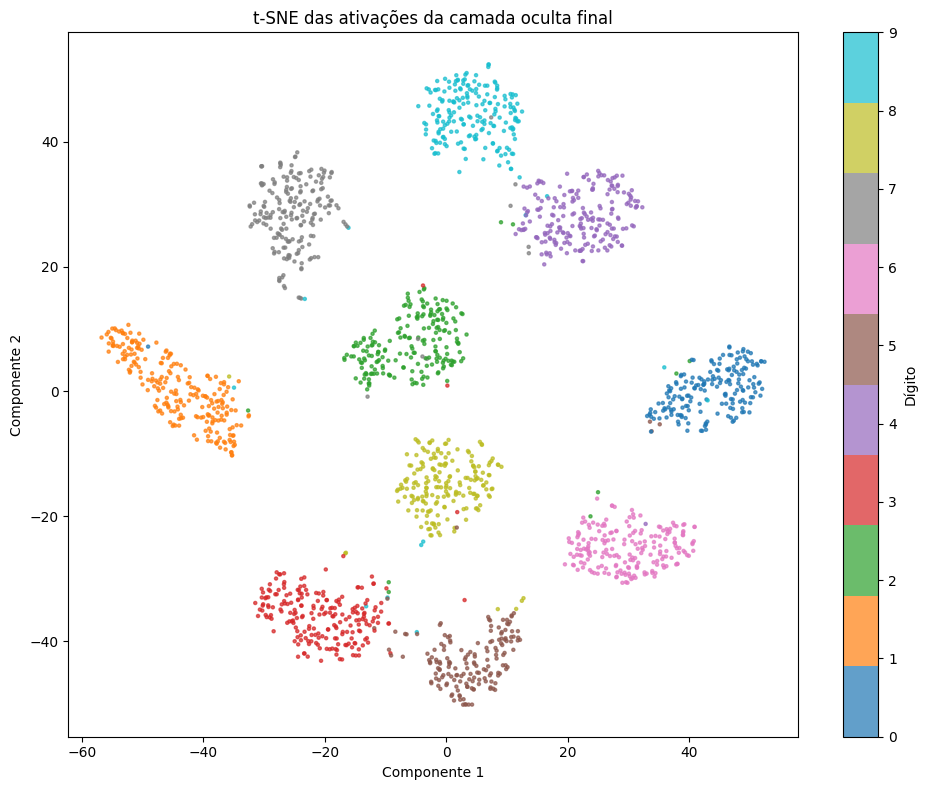

In [11]:
from sklearn.manifold import TSNE

# Extrai ativações da penúltima camada (camada 128)
sample_idx = np.random.choice(len(X_test), 2000, replace=False)
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]

# Forward pass para capturar ativações internas
model1.forward(X_sample)
embeddings = model1._cache['a'][-2]  # saída da última camada oculta

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=y_sample, cmap='tab10', s=5, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Dígito')
ax.set_title('t-SNE das ativações da camada oculta final')
ax.set_xlabel('Componente 1'); ax.set_ylabel('Componente 2')
plt.tight_layout()
plt.savefig('../results/tsne_embeddings.png', dpi=120)
plt.show()
